# Grids, Parametrized Grids & Torus - Embedding Visualisation

In [18]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    load_embeddings_batch
)

## Grid 4×4 (uncorrelated tokens)

In [6]:
ROW_COLORS = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
CTX_LENS = [300, 600, 1200, 1800]

VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
GRID_PATH  = Path("../data/one_random_walk/grid_16/grid_dataset_structure.txt")
EMB_DIR    = Path("../embeddings/one_random_walk/grid_16")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

  [] Discarded 3/302 embeddings with unknown token IDs


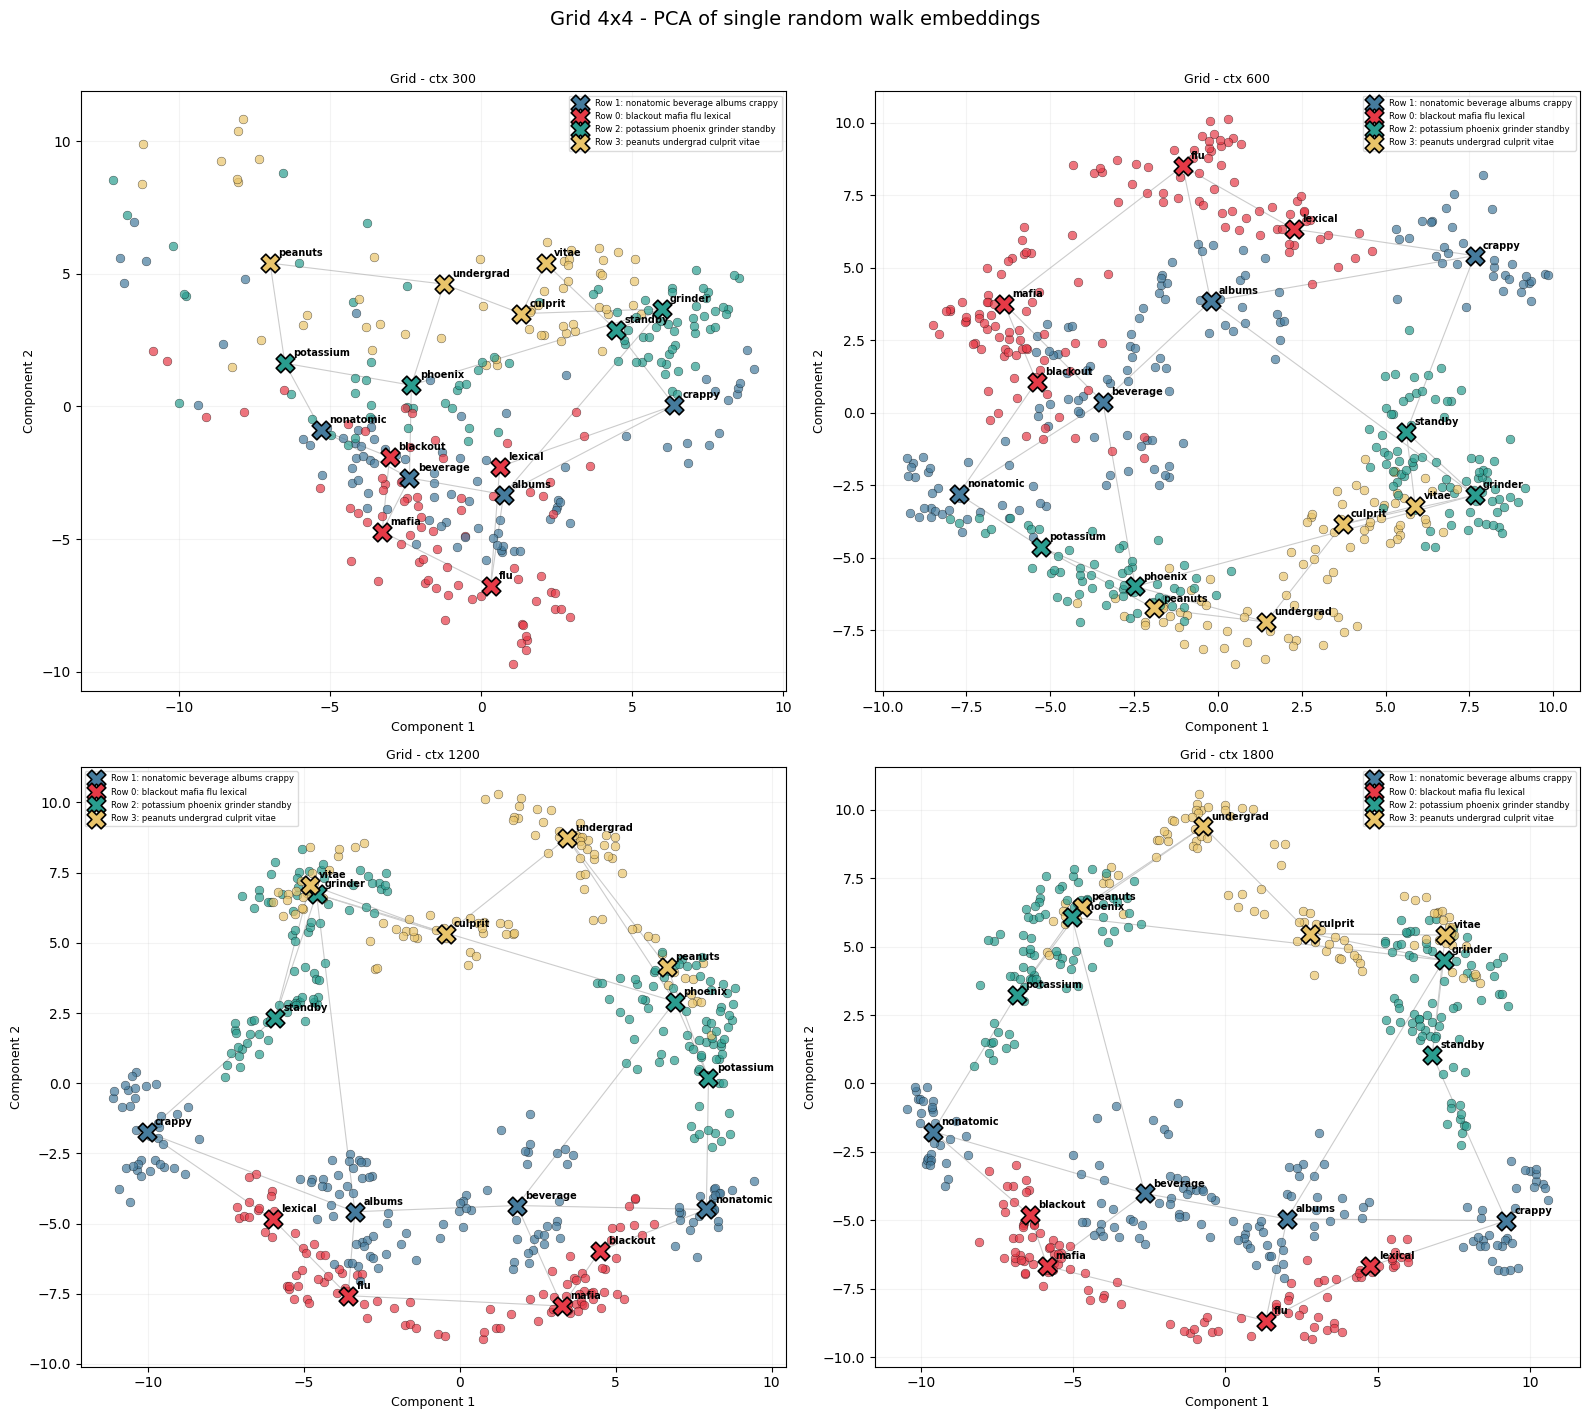

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, NW=500)
    
    pca = PCA(n_components=2, random_state=42)
    emb_pca = pca.fit_transform(filtered_emb)
    
    hp_grid.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Grid - ctx {ctx}"
    )

fig.suptitle("Grid 4x4 - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Paper Grid

In [21]:
VOCAB_PATH_PAPER = Path("../data/paper-tkid-map.txt")
GRID_PATH_PAPER  = Path("../data/one_random_walk/paper_grid/paper_grid_structure.txt")
EMB_DIR_PAPER    = Path("../embeddings/one_random_walk/paper_grid")

hp_paper = Plotter(VOCAB_PATH_PAPER, GRID_PATH_PAPER, EMB_DIR_PAPER)

  [] Discarded 2/301 embeddings with unknown token IDs


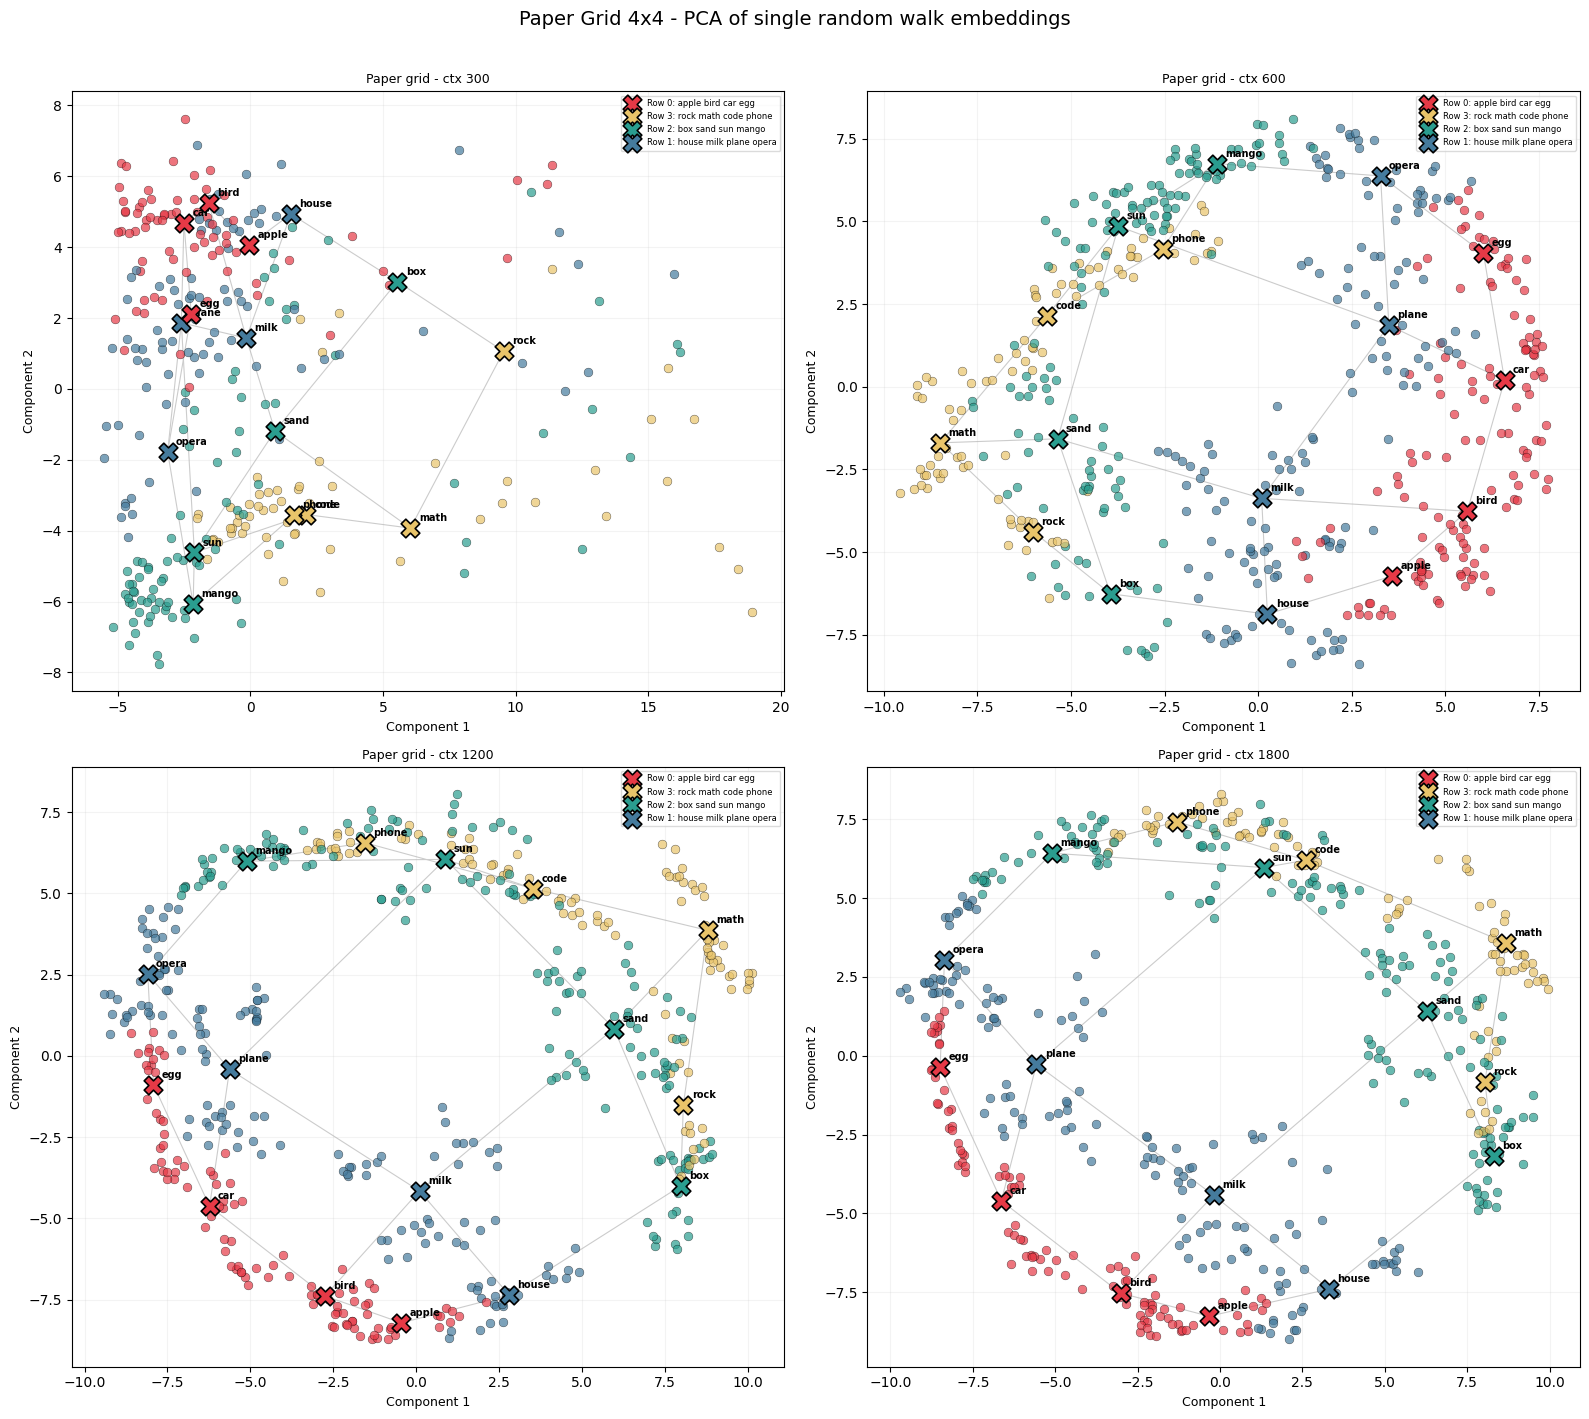

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR_PAPER / f"reprs_paper_grid_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_paper.id_to_word, NW=500)
    
    pca = PCA(n_components=2, random_state=42)
    emb_pca = pca.fit_transform(filtered_emb)
    
    hp_paper.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Paper grid - ctx {ctx}"
    )

fig.suptitle("Paper Grid 4x4 - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Parametrized Grid 4×4

In [23]:
STRUCT_PATH_PG = Path("../data/one_random_walk/parametrized_grid_16/grid_dataset_structure.txt")
EMB_DIR_PG     = Path("../embeddings/one_random_walk/parametrized_grid_16")

hp_pg = Plotter(VOCAB_PATH, STRUCT_PATH_PG, EMB_DIR_PG)

### PCA 2D

  [] Discarded 3/302 embeddings with unknown token IDs


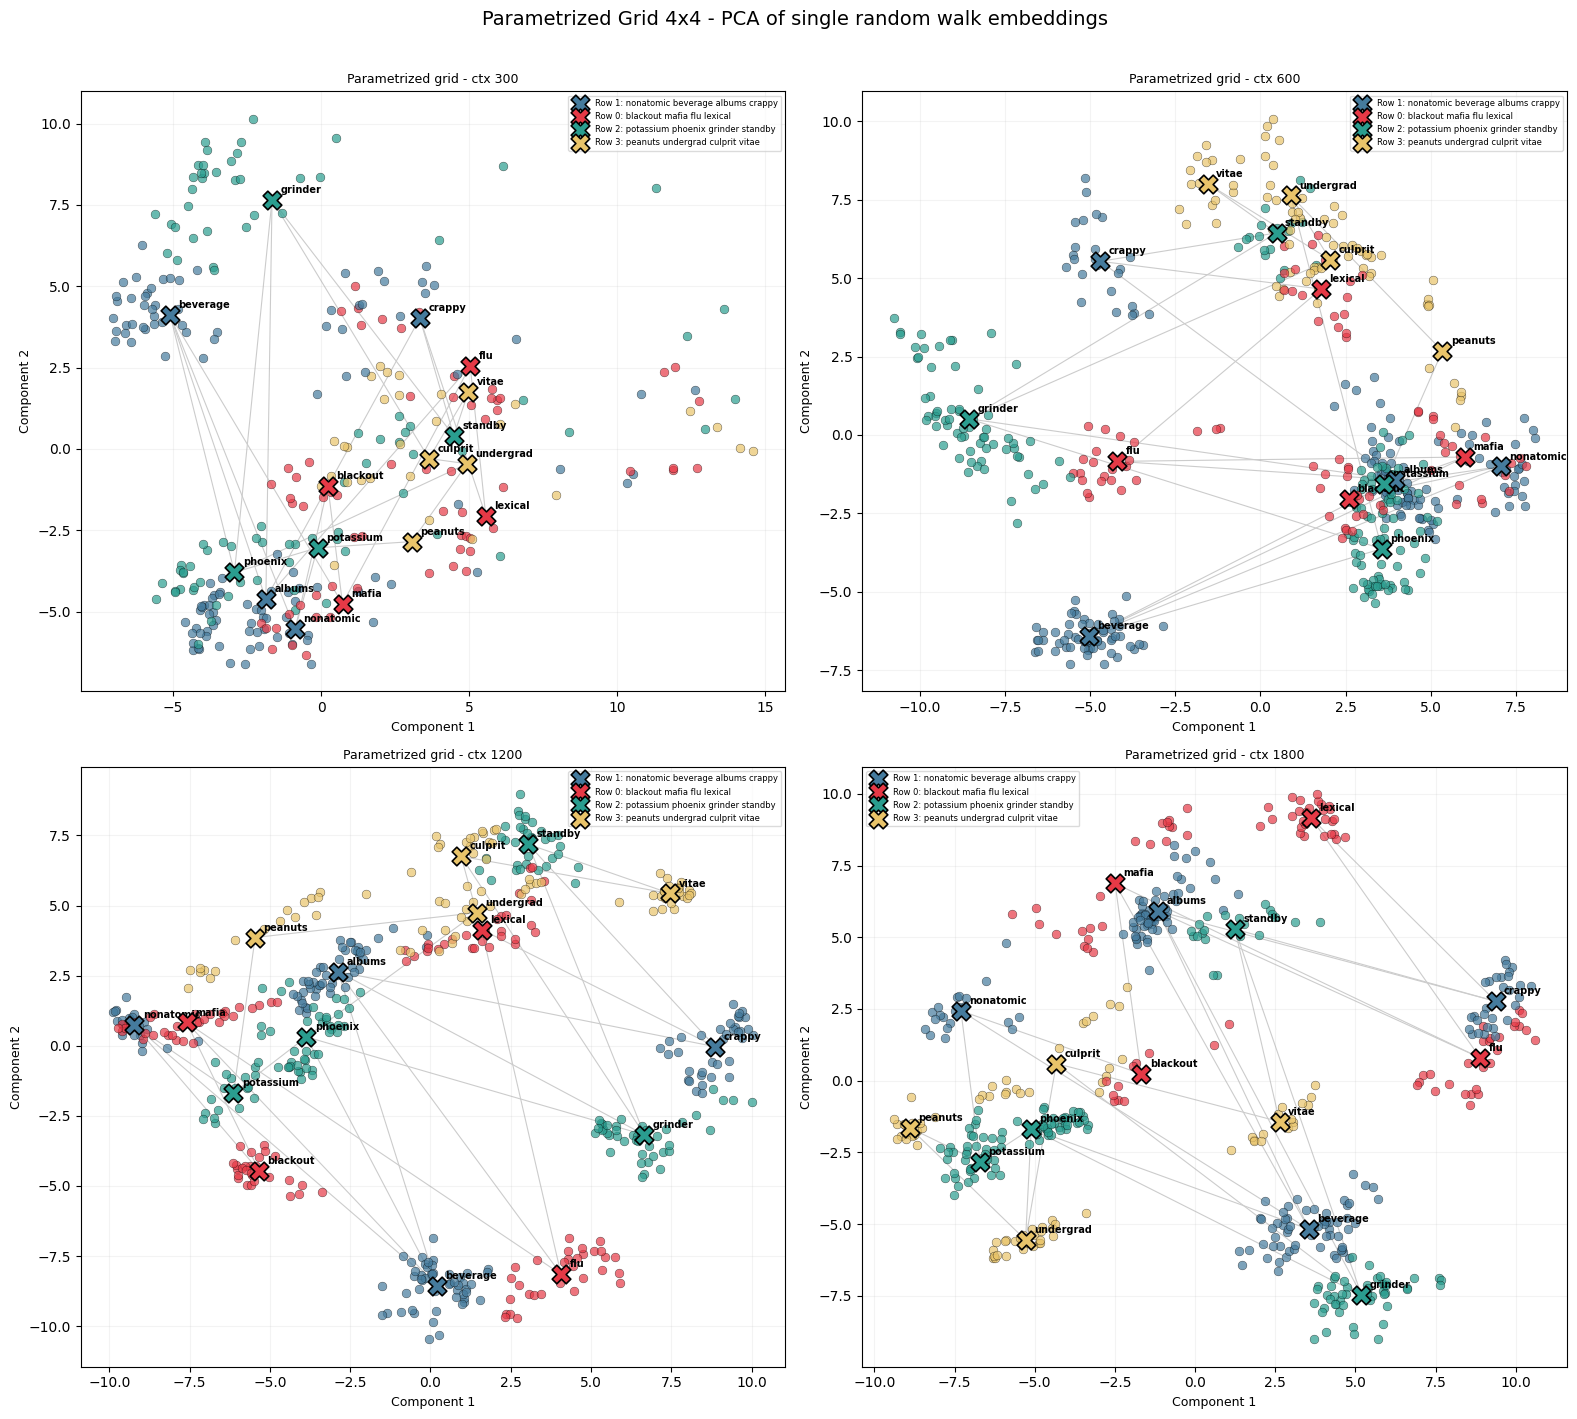

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR_PG / f"reprs_grid_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_pg.id_to_word, NW=500)
    
    pca = PCA(n_components=2, random_state=42)
    emb_pca = pca.fit_transform(filtered_emb)

    hp_pg.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Parametrized grid - ctx {ctx}",
    )

fig.suptitle("Parametrized Grid 4x4 - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 2D

  [] Discarded 3/302 embeddings with unknown token IDs


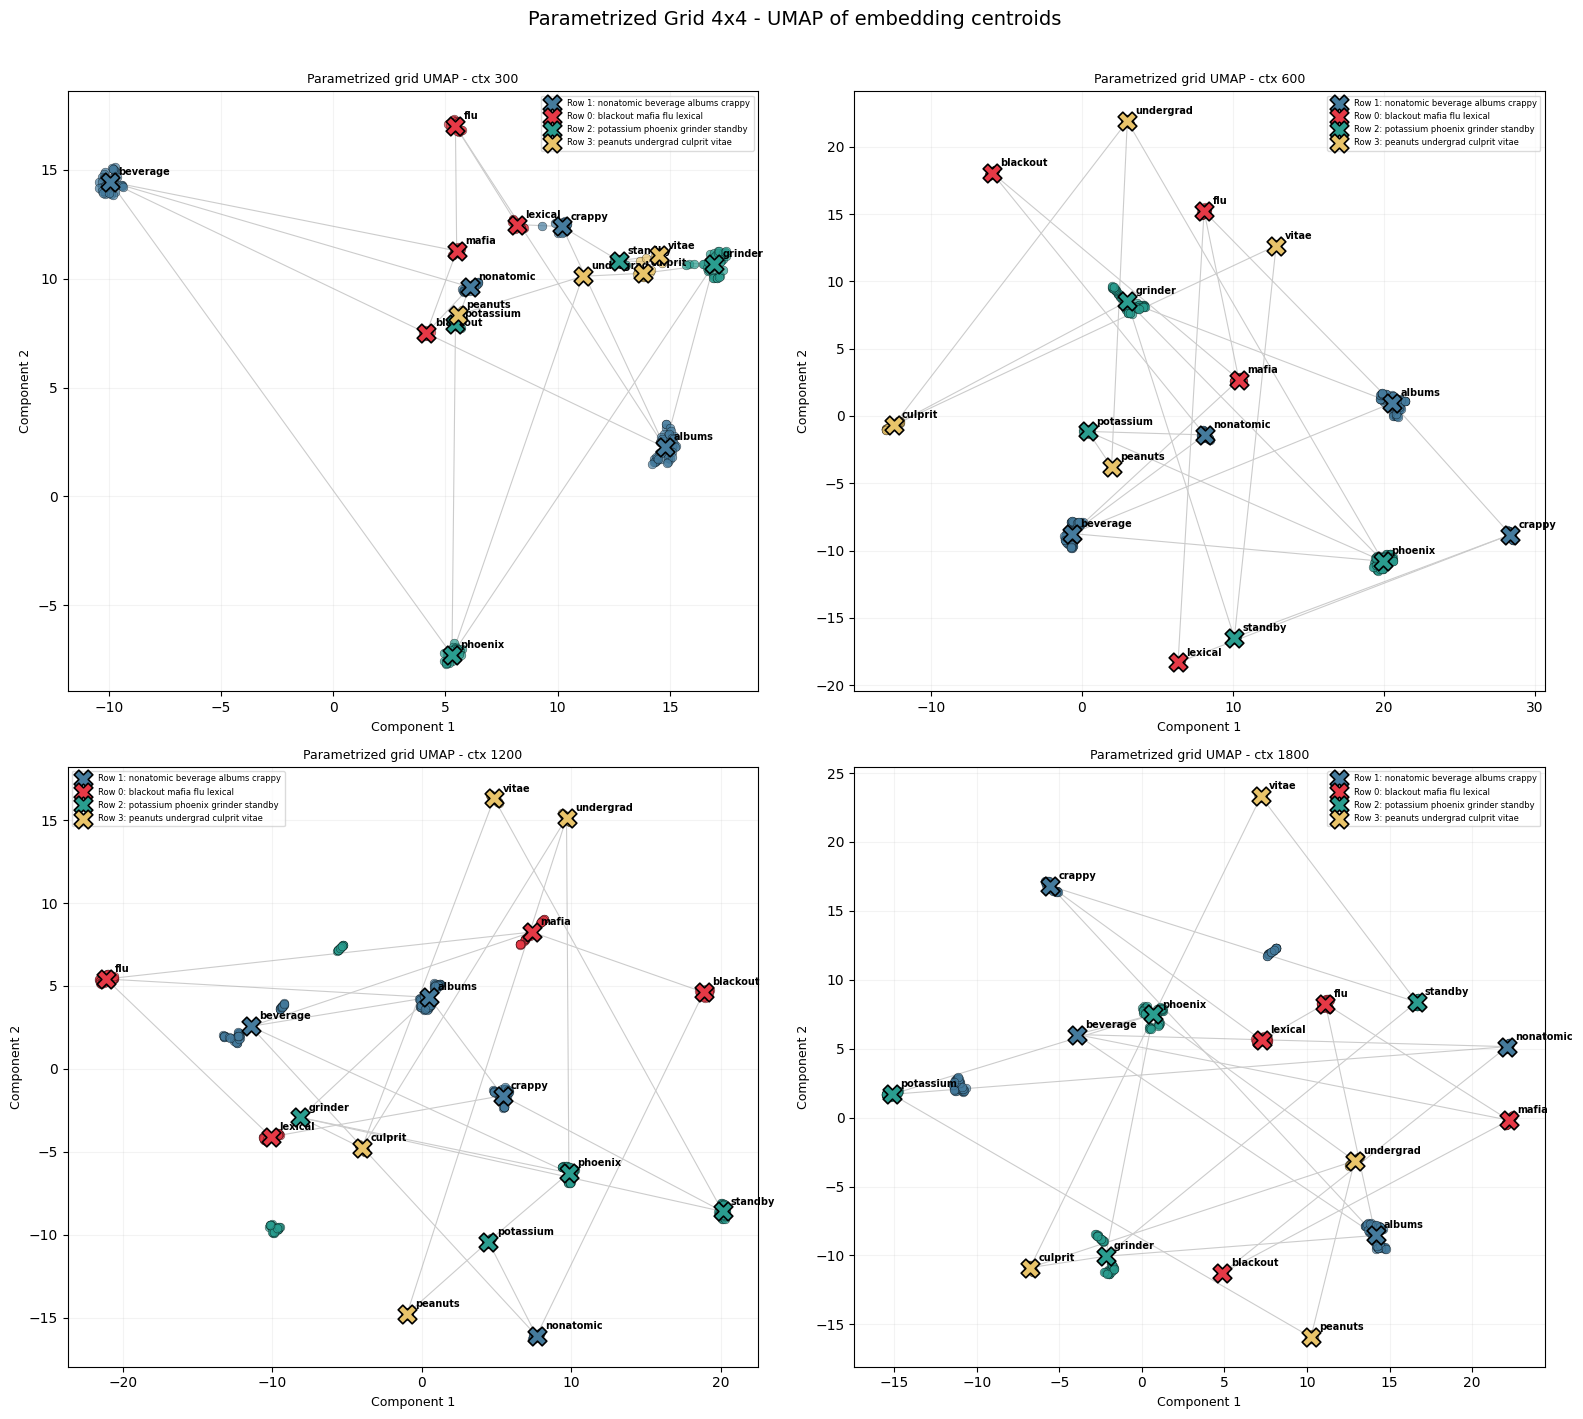

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR_PG / f"reprs_grid_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_pg.id_to_word, NW=500)
    reduced_emb = umap.UMAP(n_components=2, random_state=42, n_jobs=1).fit_transform(filtered_emb)

    hp_pg.plot_reduced_emb(
        ax, reduced_emb=reduced_emb, win_ids=filtered_ids, title=f"Parametrized grid UMAP - ctx {ctx}",
    )

fig.suptitle("Parametrized Grid 4x4 - UMAP of embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Torus 4x4

In [7]:
STRUCT_PATH_T = Path("../data/one_random_walk/torus_16/torus_dataset_structure.txt")
EMB_DIR_T     = Path("../embeddings/one_random_walk/torus_16")

hp_torus = Plotter(VOCAB_PATH, STRUCT_PATH_T, EMB_DIR_T)

### PCA 3D

  [] Discarded 3/302 embeddings with unknown token IDs


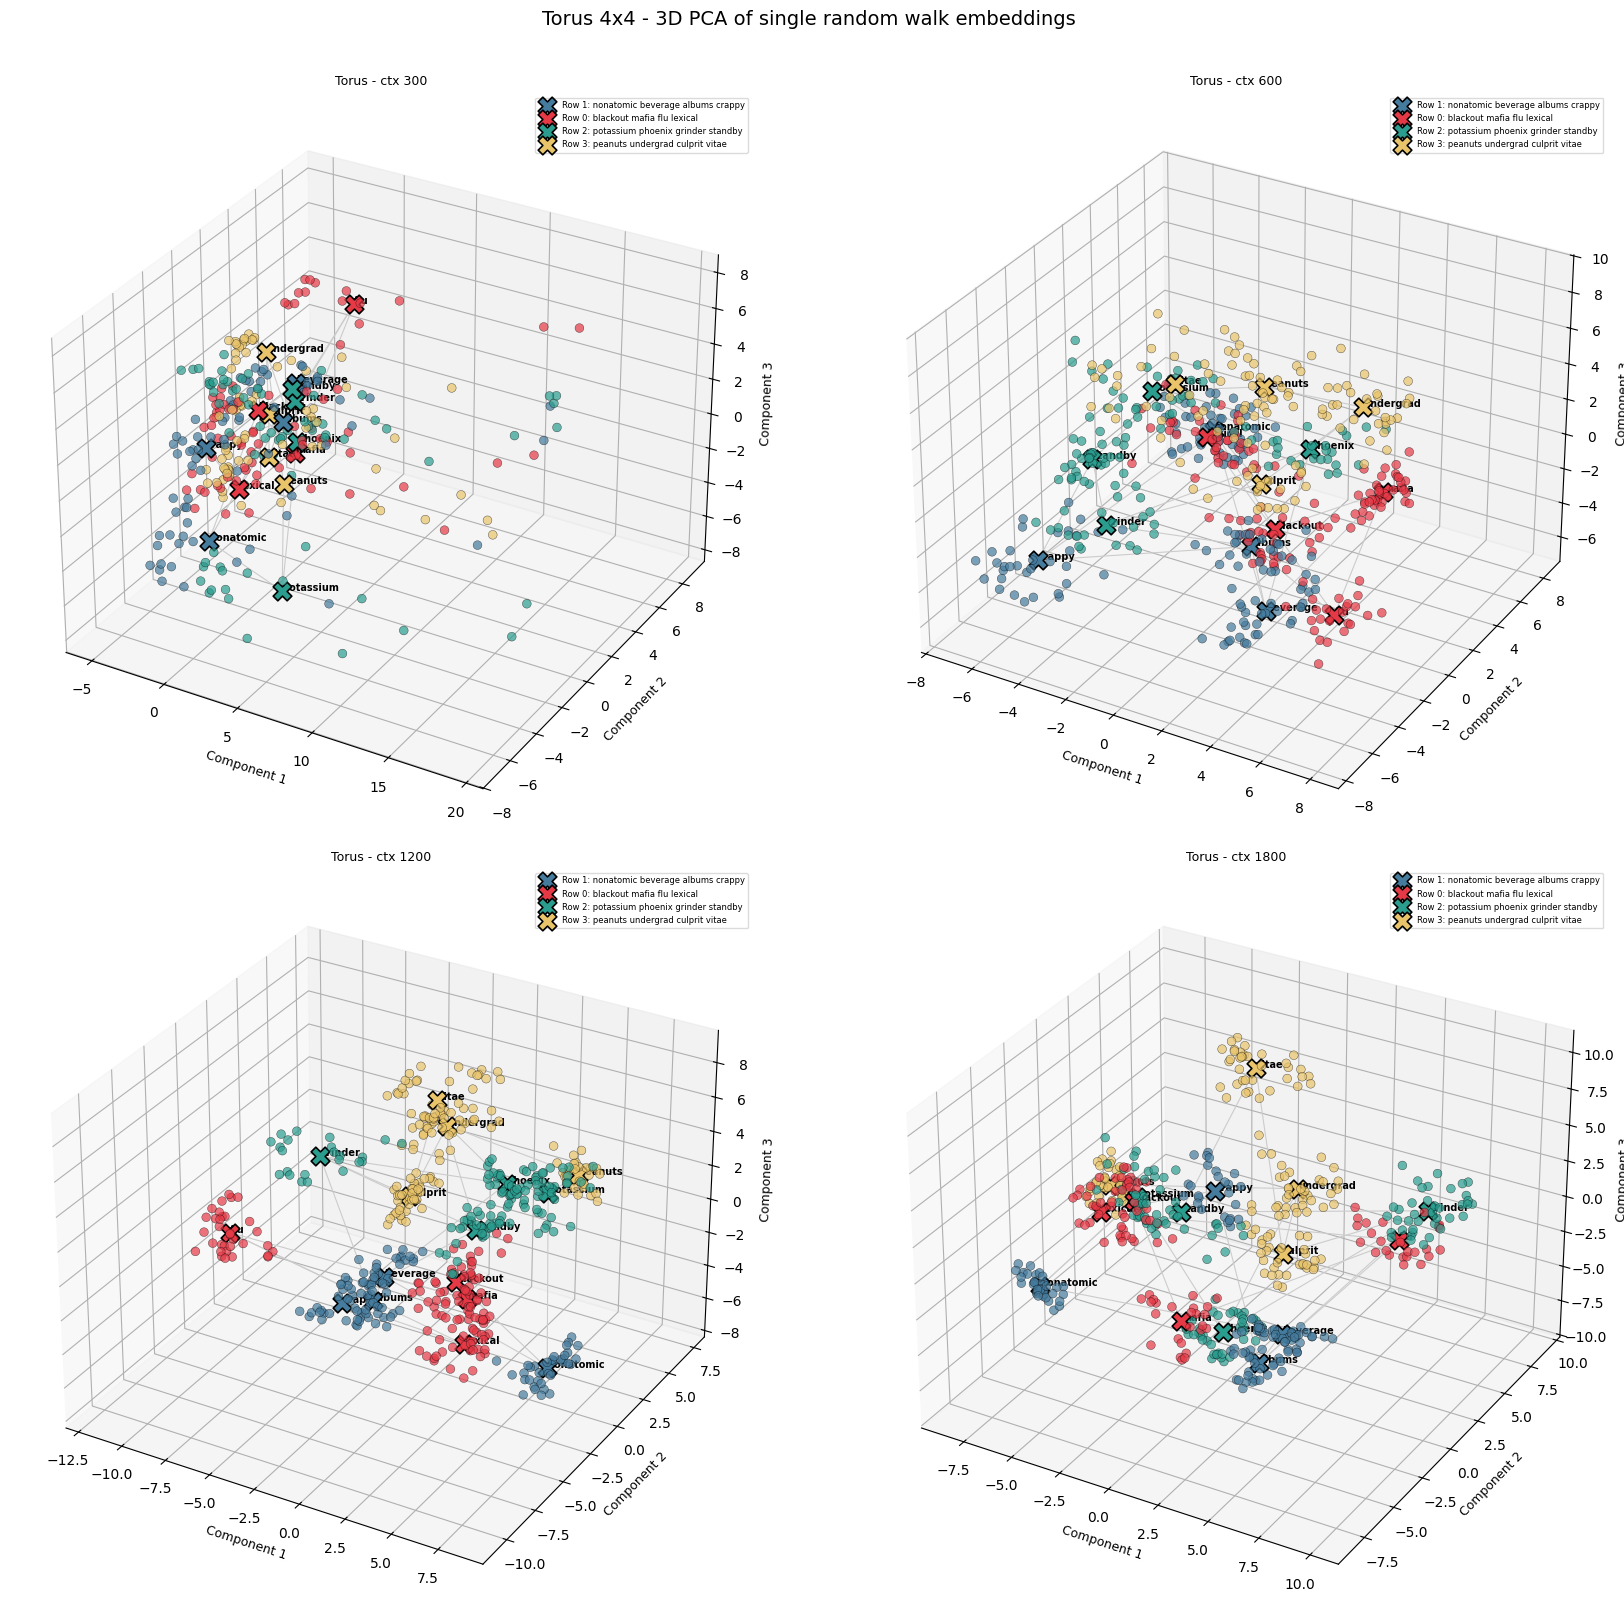

In [8]:
fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    pt_path = EMB_DIR_T / f"reprs_torus_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_torus.id_to_word, NW=500)

    pca = PCA(n_components=3, random_state=42)
    emb_pca = pca.fit_transform(filtered_emb)

    hp_torus.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Torus - ctx {ctx}",
    )

fig.suptitle("Torus 4x4 - 3D PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 3D

  [] Discarded 3/302 embeddings with unknown token IDs


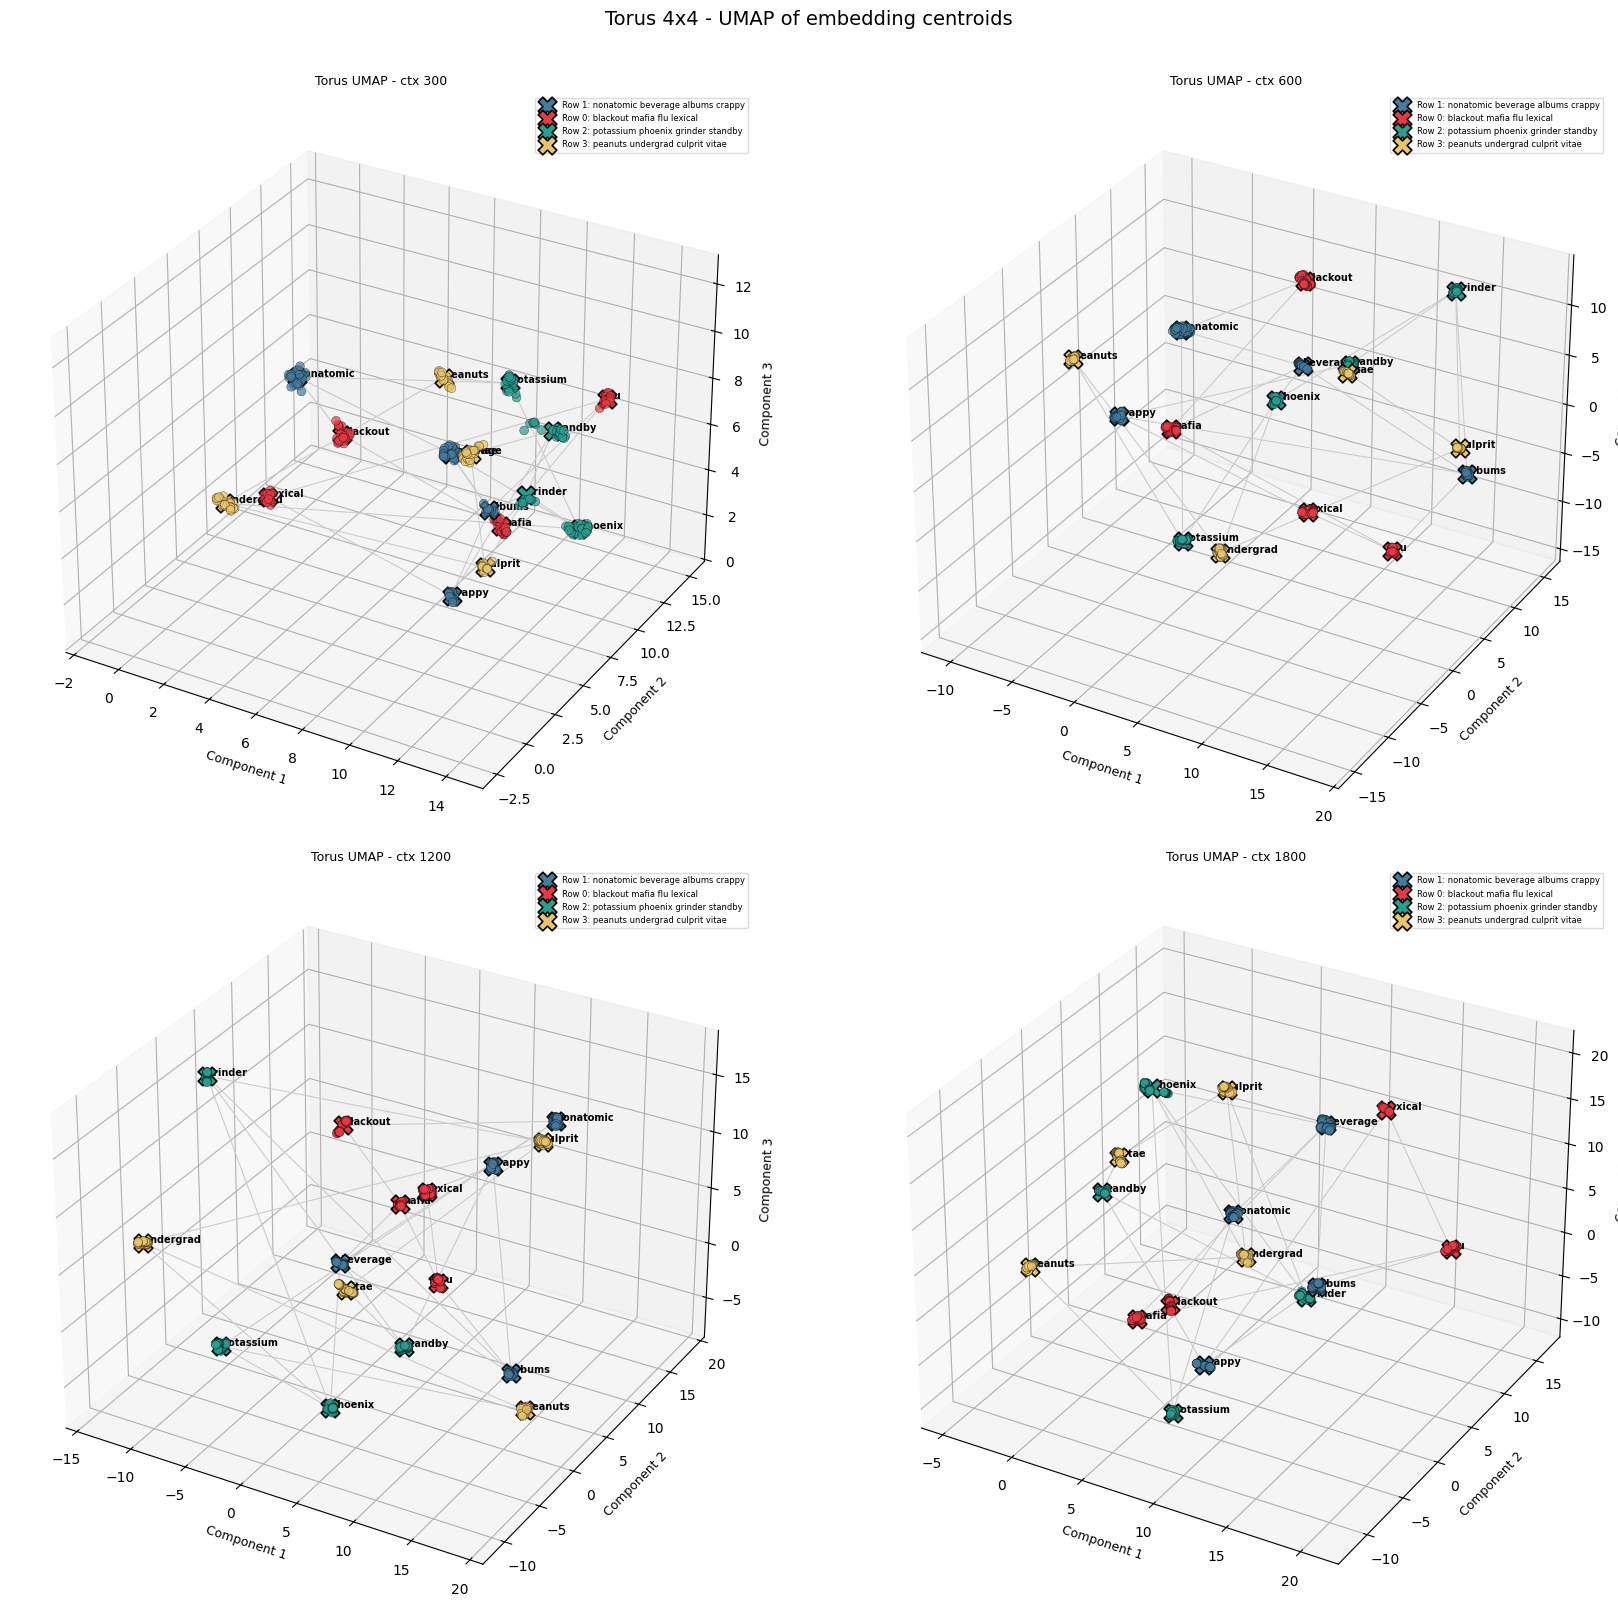

In [14]:
fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    pt_path = EMB_DIR_T / f"reprs_torus_dataset_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_torus.id_to_word, NW=500)

    emb_umap = umap.UMAP(n_components=3, random_state=42, n_jobs=1).fit_transform(filtered_emb)

    hp_torus.plot_reduced_emb(
        ax, reduced_emb=emb_umap, win_ids=filtered_ids, title=f"Torus UMAP - ctx {ctx}"
    )

fig.suptitle("Torus 4x4 - UMAP of embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# Multi-batch Grid Embeddings

Same grid structures as above, but using **multi-batch** embeddings.
For each context length we load **B** independent random-walk files (one per
grid node), take the last **NW** tokens from each, concatenate, and pass the
pooled embeddings to the same plotting routines.

## Grid 4×4 (multi-batch)

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


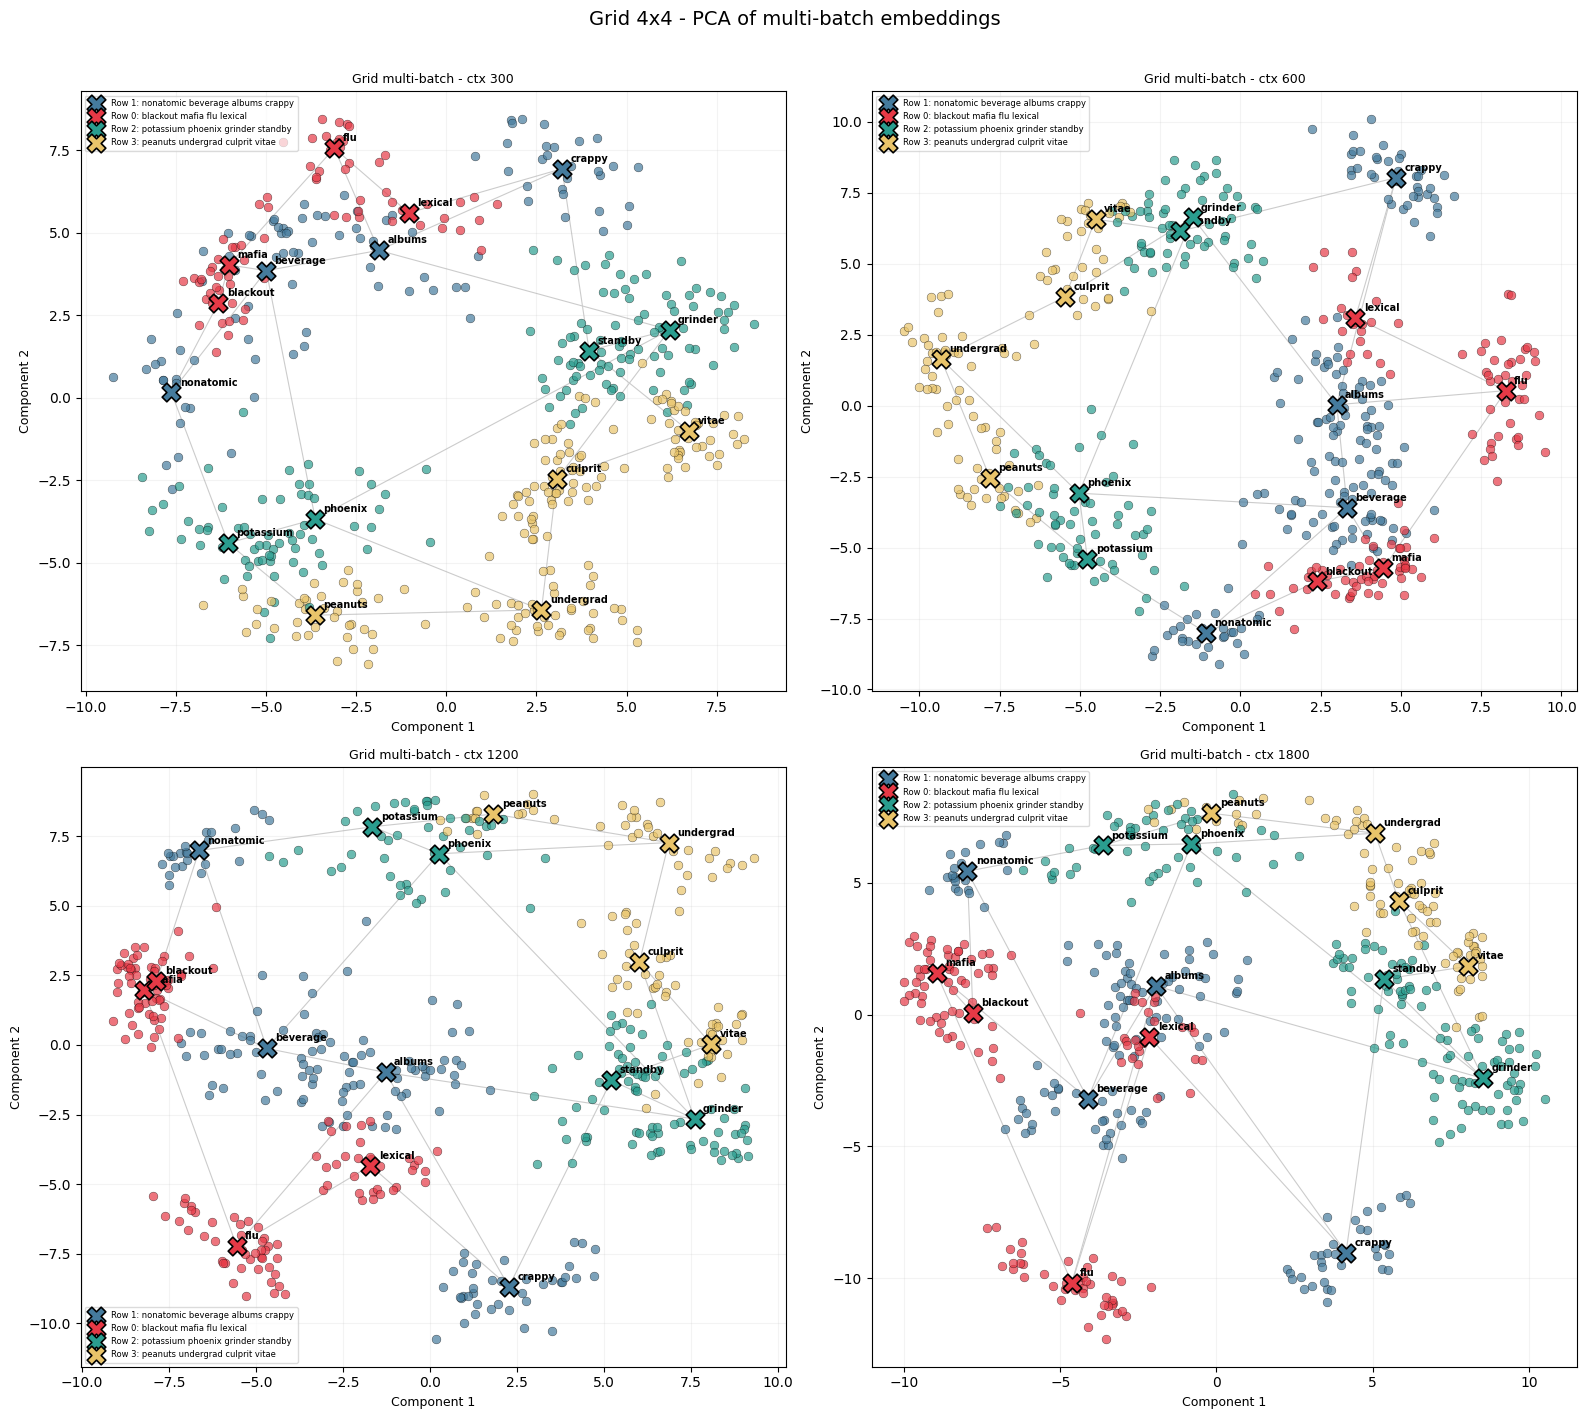

In [15]:
EMB_DIR_MB = Path("../embeddings/multi_batch/grid_16")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR_MB)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB, ctx, NW=50)
    
    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, NW=500)
    pca = PCA(n_components=2, random_state=42)
    emb_pca = pca.fit_transform(filtered_emb)

    hp_grid.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Grid multi-batch - ctx {ctx}",
    )

fig.suptitle("Grid 4x4 - PCA of multi-batch embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Paper Grid (multi-batch)

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


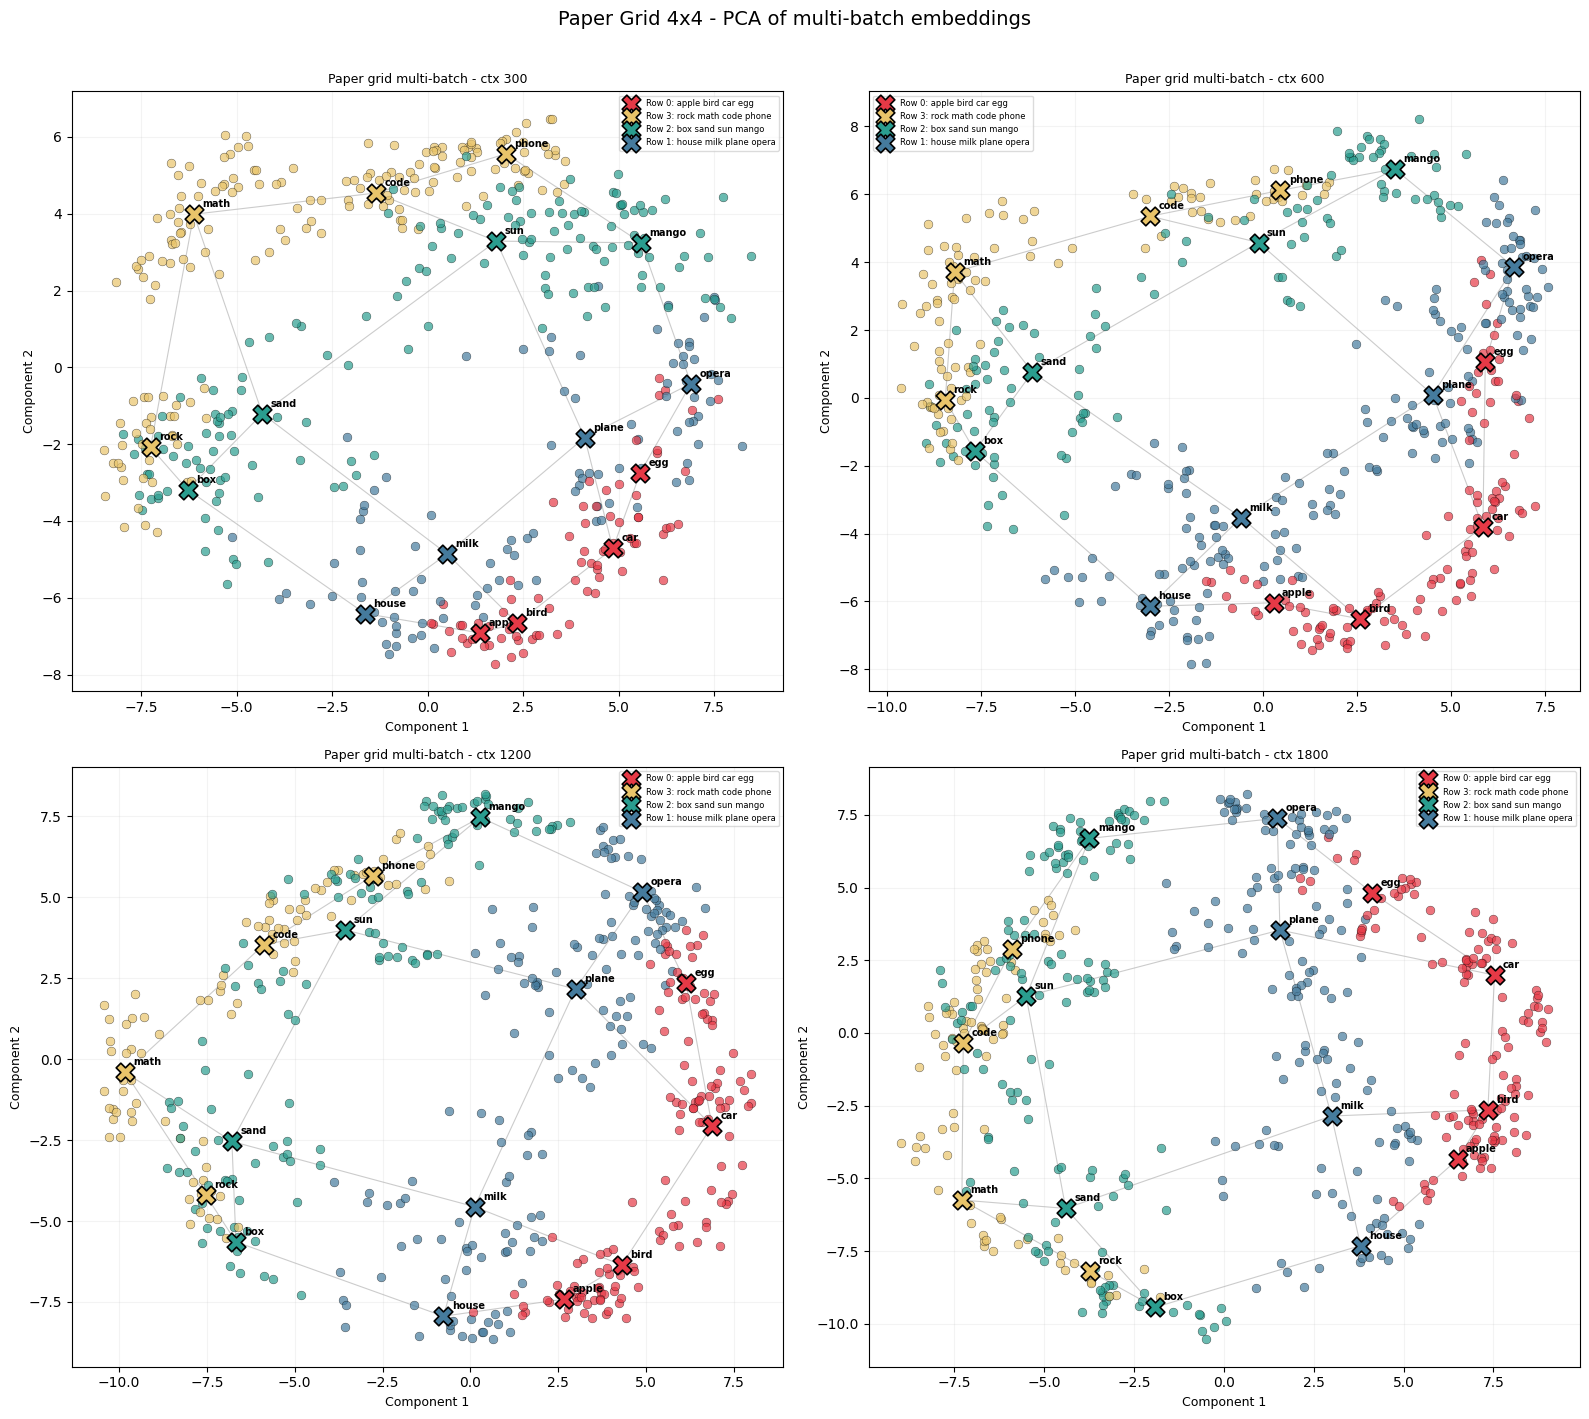

In [17]:
EMB_DIR_MB_P = Path("../embeddings/multi_batch/paper_grid")
VOCAB_PATH_PAPER = Path("../data/paper-tkid-map.txt")
GRID_PATH_PAPER  = Path("../data/one_random_walk/paper_grid/paper_grid_structure.txt")
EMB_DIR_PAPER    = Path("../embeddings/one_random_walk/paper_grid")

hp_paper = Plotter(VOCAB_PATH_PAPER, GRID_PATH_PAPER, EMB_DIR_MB_P)


fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_P, ctx, NW=50)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_paper.id_to_word, NW=500)
    pca = PCA(n_components=2, random_state=42)
    emb_pca = pca.fit_transform(filtered_emb)

    hp_paper.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Paper grid multi-batch - ctx {ctx}",
    )

fig.suptitle("Paper Grid 4x4 - PCA of multi-batch embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Parametrized Grid 4×4 (multi-batch)

### PCA 2D

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


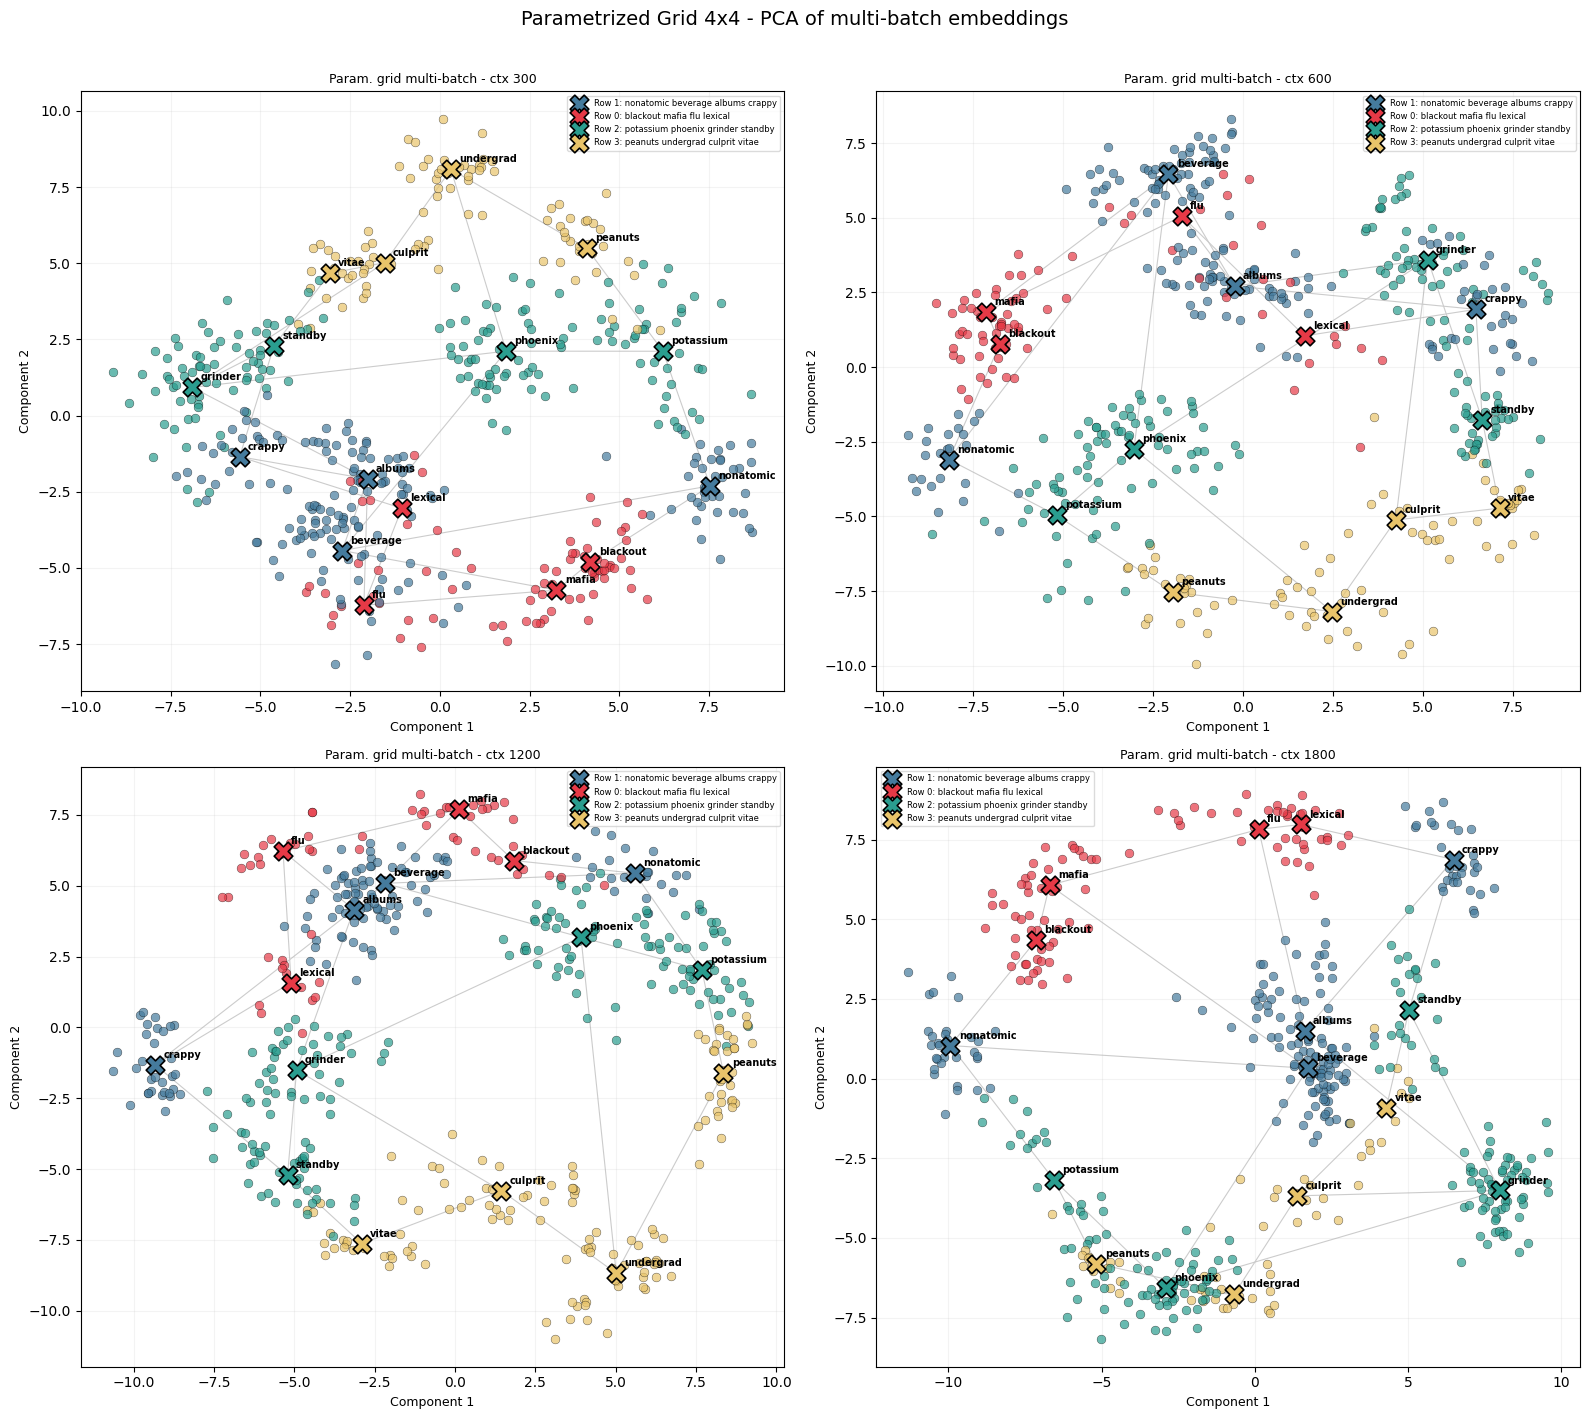

In [22]:
EMB_DIR_MB_PG = Path("../embeddings/multi_batch/parametrized_grid_16")
STRUCT_PATH_PG = Path("../data/one_random_walk/parametrized_grid_16/grid_dataset_structure.txt")
EMB_DIR_PG     = Path("../embeddings/one_random_walk/parametrized_grid_16")

hp_pg = Plotter(VOCAB_PATH, STRUCT_PATH_PG, EMB_DIR_PG)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_PG, ctx, NW=50)
    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_pg.id_to_word, NW=500)
    pca = PCA(n_components=2, random_state=42)
    emb_pca = pca.fit_transform(filtered_emb)
    hp_pg.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Param. grid multi-batch - ctx {ctx}"
    )

fig.suptitle("Parametrized Grid 4x4 - PCA of multi-batch embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 2D

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


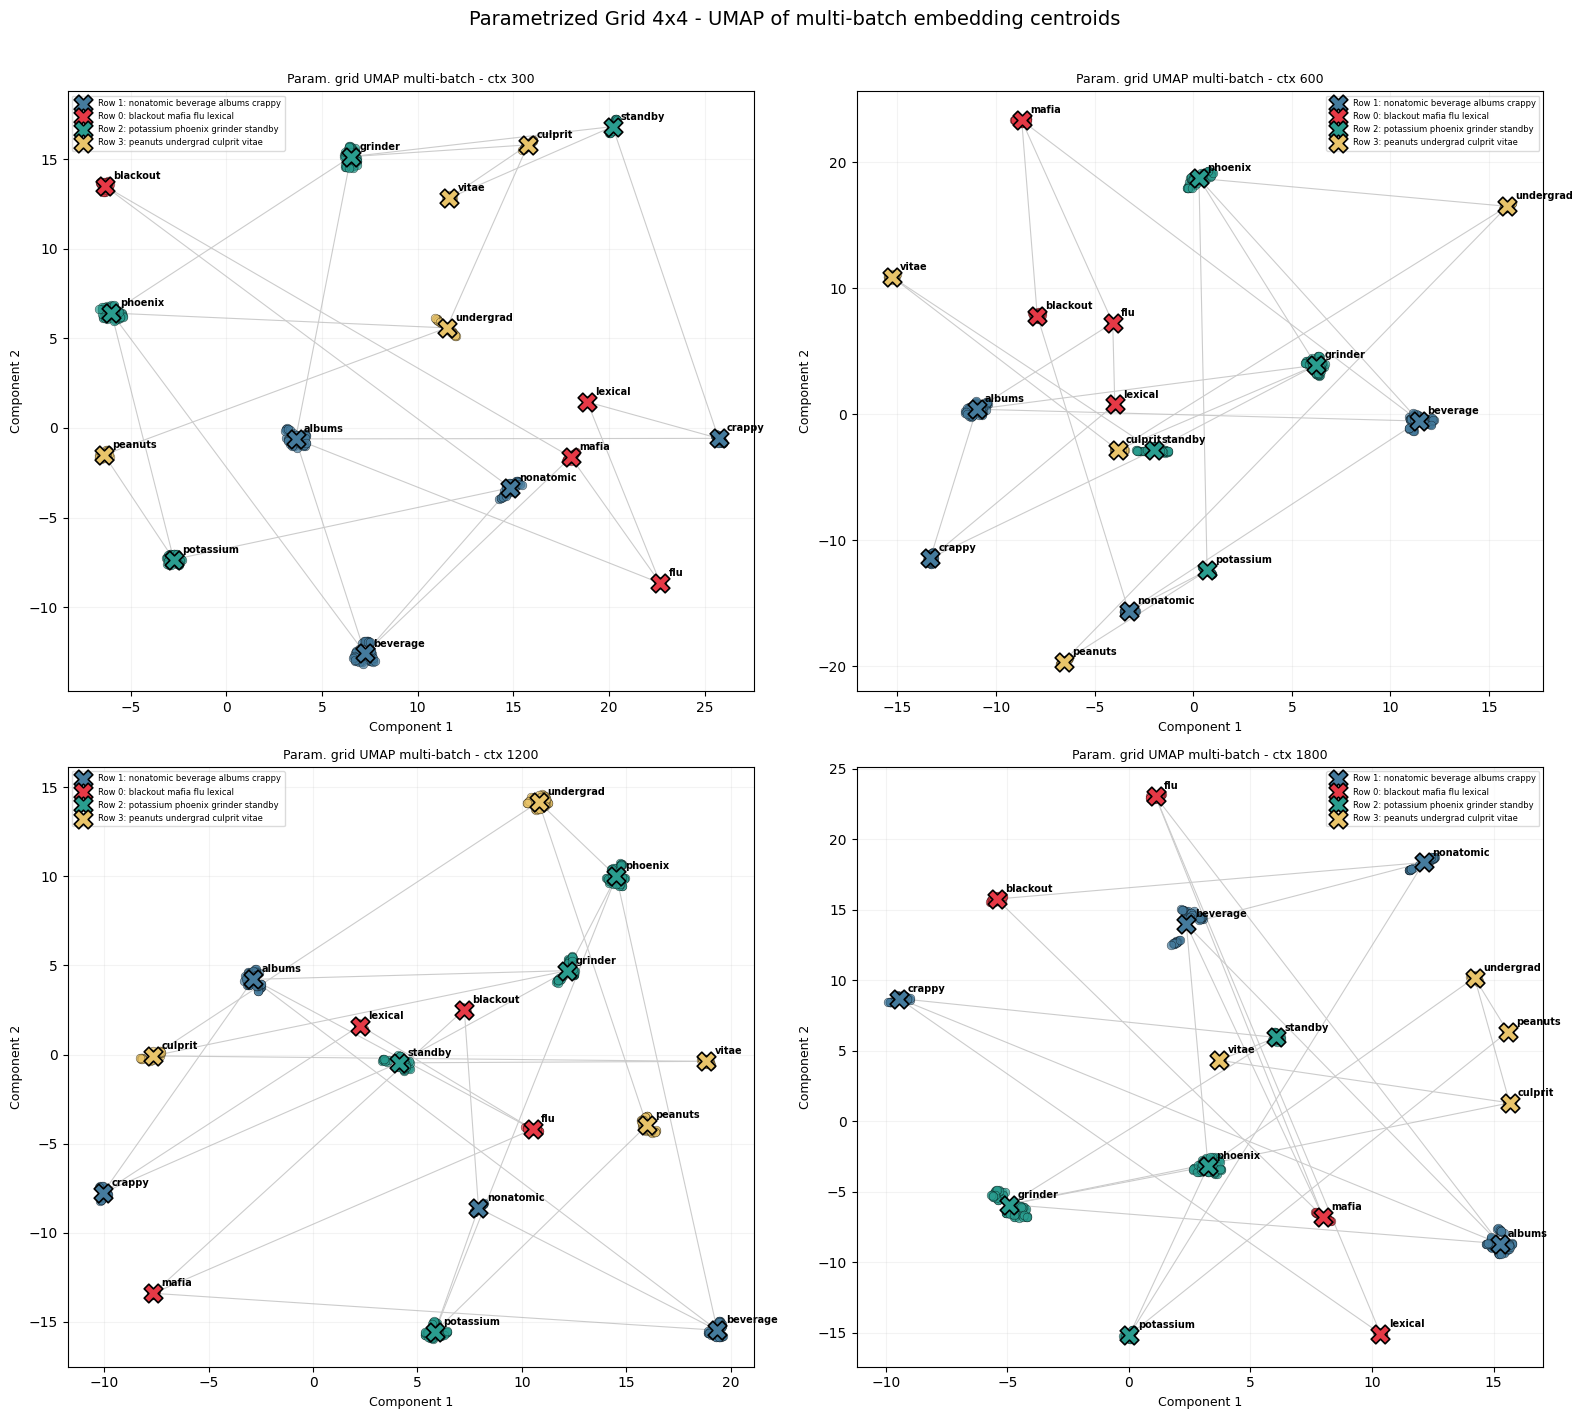

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ctx in zip(axes.flat, CTX_LENS):
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_PG, ctx, NW=50)
    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_pg.id_to_word, NW=500)
    emb_umap = umap.UMAP(n_components=2, random_state=42, n_jobs=1).fit_transform(filtered_emb)

    hp_pg.plot_reduced_emb(
        ax, reduced_emb=emb_umap, win_ids=filtered_ids, title=f"Param. grid UMAP multi-batch - ctx {ctx}",
    )
fig.suptitle("Parametrized Grid 4x4 - UMAP of multi-batch embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Torus 4×4 (multi-batch)

### PCA 3D

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


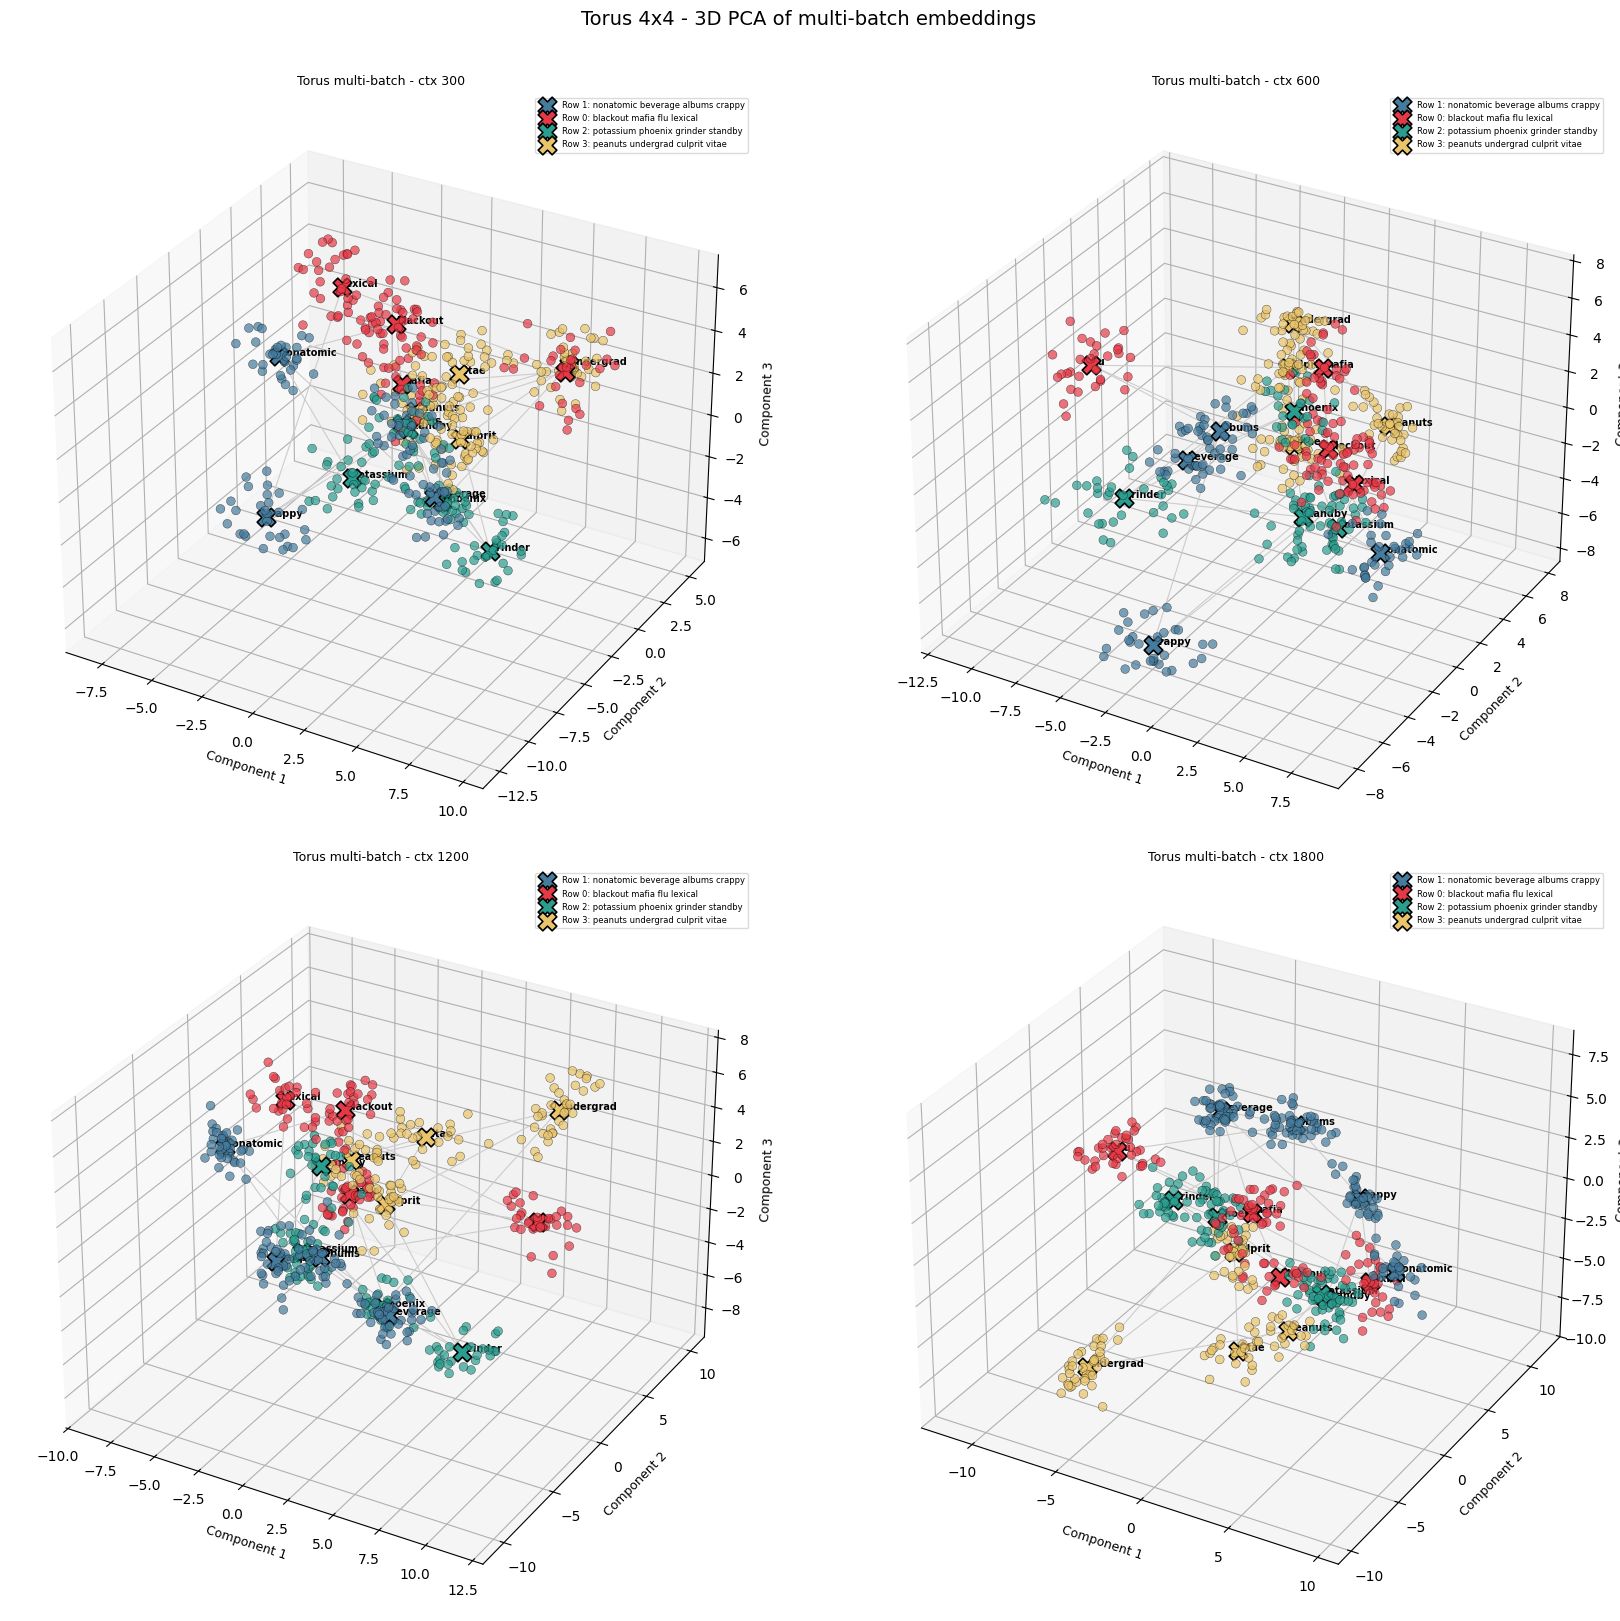

In [26]:
EMB_DIR_MB_T = Path("../embeddings/multi_batch/torus_16")
STRUCT_PATH_T = Path("../data/one_random_walk/torus_16/torus_dataset_structure.txt")
EMB_DIR_T     = Path("../embeddings/one_random_walk/torus_16")

hp_torus = Plotter(VOCAB_PATH, STRUCT_PATH_T, EMB_DIR_T)

fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_T, ctx, NW=50)
    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_torus.id_to_word, NW=500)
    pca = PCA(n_components=3, random_state=42)
    emb_pca = pca.fit_transform(filtered_emb)

    hp_torus.plot_reduced_emb(
        ax, reduced_emb=emb_pca, win_ids=filtered_ids, title=f"Torus multi-batch - ctx {ctx}",
    )

fig.suptitle("Torus 4x4 - 3D PCA of multi-batch embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### UMAP 3D

Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096
Loaded batch: B=16, NW=50, total pooled=800, d=4096


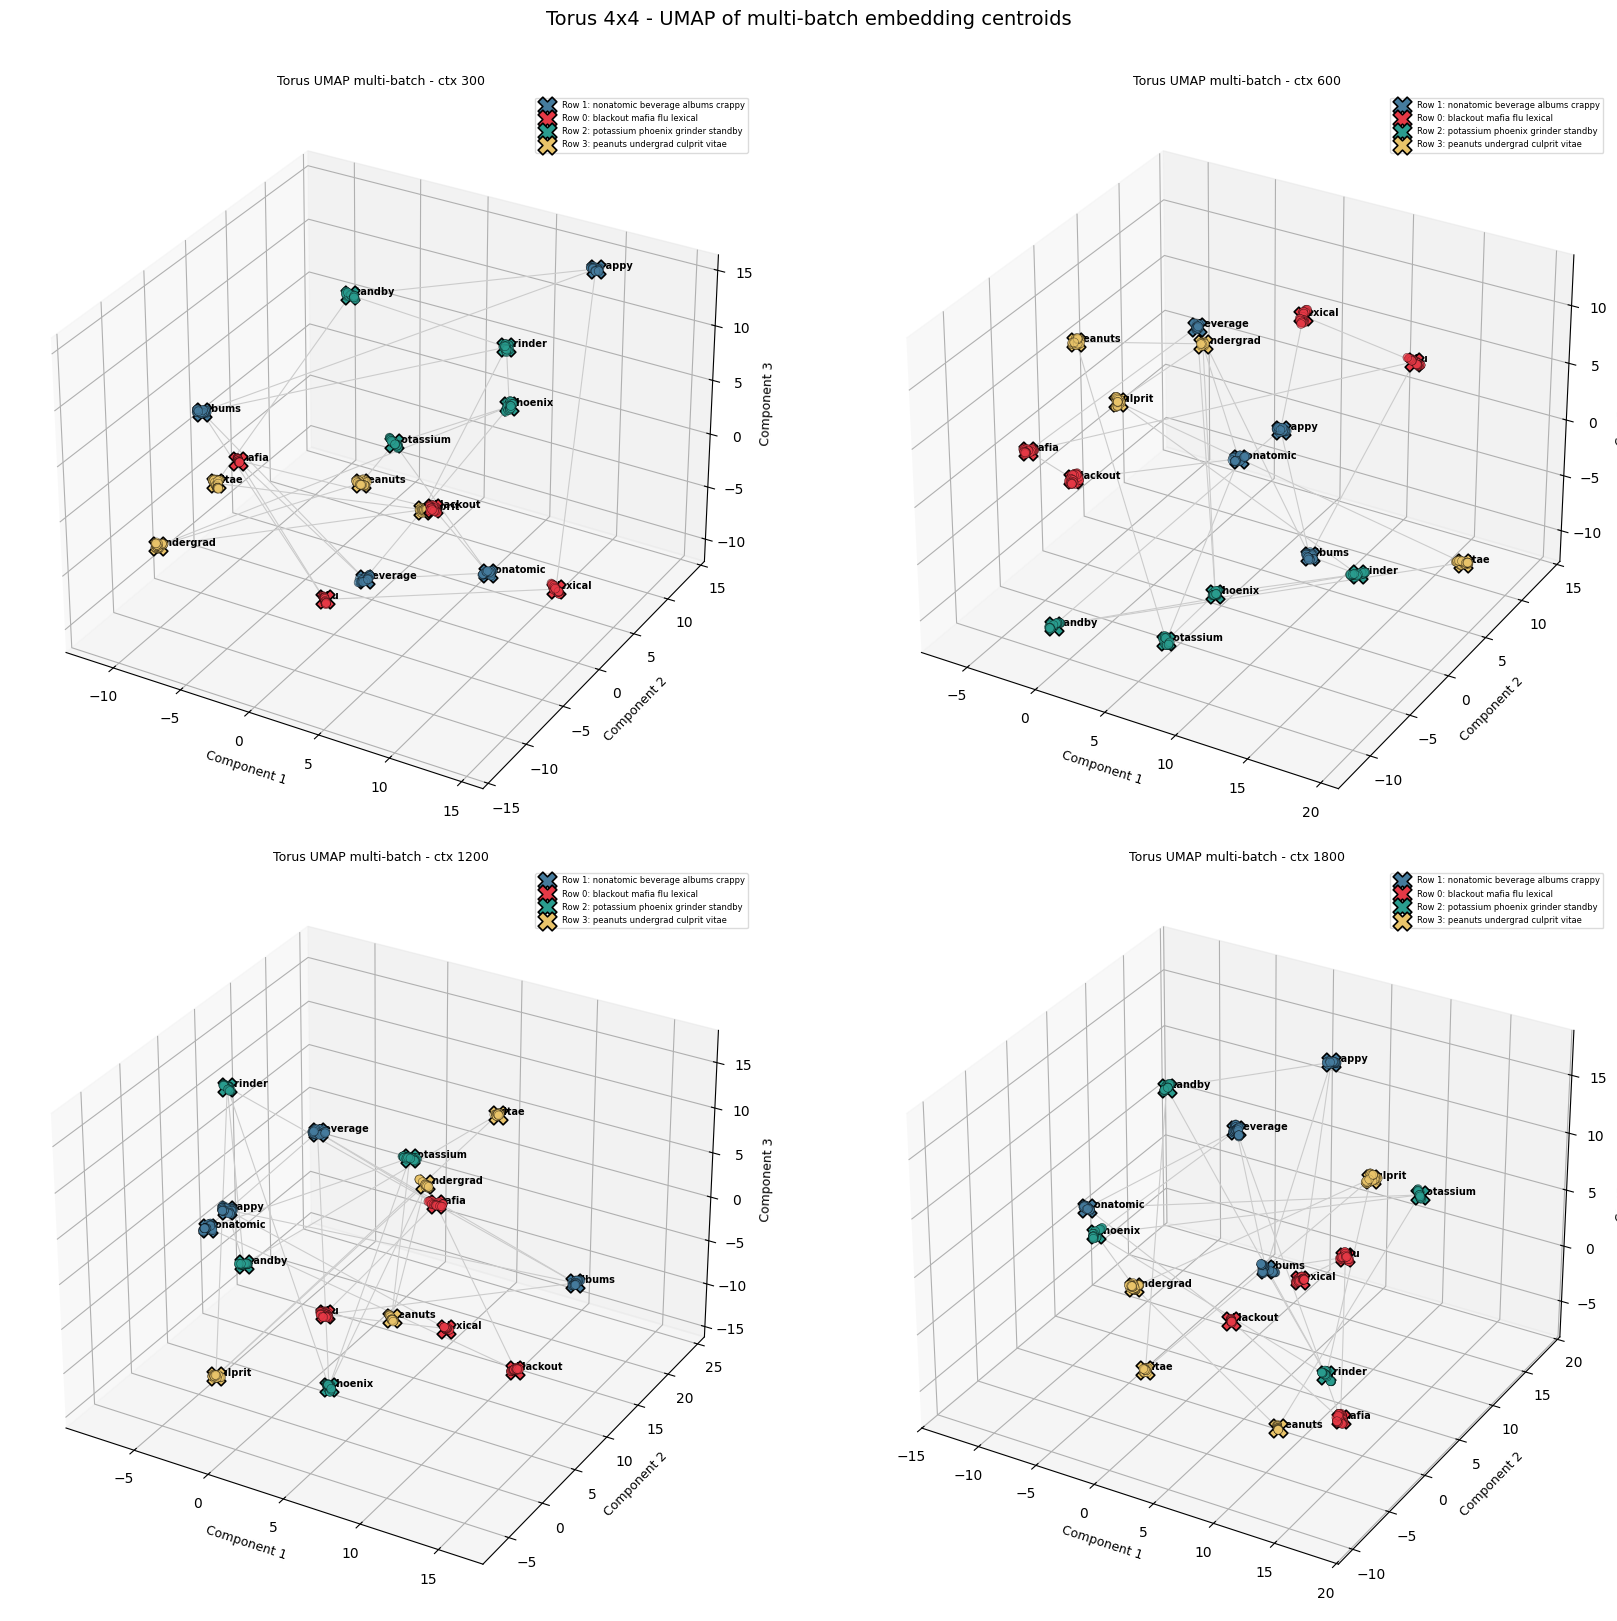

In [27]:
fig = plt.figure(figsize=(18, 16))

for i, ctx in enumerate(CTX_LENS, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    ids_np, emb_np = load_embeddings_batch(EMB_DIR_MB_T, ctx, NW=50)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_torus.id_to_word, NW=500)
    emb_umap = umap.UMAP(n_components=3, random_state=42, n_jobs=1).fit_transform(filtered_emb)
    hp_torus.plot_reduced_emb(
        ax, reduced_emb=emb_umap, win_ids=filtered_ids, title=f"Torus UMAP multi-batch - ctx {ctx}"
    )


fig.suptitle("Torus 4x4 - UMAP of multi-batch embedding centroids",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()